<a href="https://colab.research.google.com/github/rabyaibtesam-lgtm/Machine-learning/blob/main/decision_tree_model_pkl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gauravjhaeigenvector/ai-impact-on-health")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-impact-on-health' dataset.
Path to dataset files: /kaggle/input/ai-impact-on-health


In [ ]:
import os
import pandas as pd

# List files in the dataset directory and find CSVs
print("Files in dataset directory:")
csv_files = []
for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        full_path = os.path.join(dirname, filename)
        print(full_path)
        if full_path.endswith('.csv'):
            csv_files.append(full_path)

if not csv_files:
    raise FileNotFoundError("No CSV files found in the dataset directory.")

# Assuming the first CSV file found is the main data file.
# If there are multiple, you might need to specify which one manually.
data_file = csv_files[0]
print(f"\nLoading data from: {data_file}")

# Load the dataset
df = pd.read_csv(data_file)

# Display the first 5 rows and information about the dataframe
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDataFrame Info:")
df.info()

Files in dataset directory:
/kaggle/input/ai-impact-on-health/AI_Impact_on_Health_Dataset_5000_Enhanced.csv

Loading data from: /kaggle/input/ai-impact-on-health/AI_Impact_on_Health_Dataset_5000_Enhanced.csv

First 5 rows of the dataset:


,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Participant_ID                      5000 non-null   int64  
 1   Age                                 5000 non-null   int64  
 2   Age_Group                           5000 non-null   object 
 3   Gender                              5000 non-null   object 
 4   Chronic_Condition                   5000 non-null   object 
 5   BMI                                 5000 non-null   float64
 6   BMI_Category                        5000 non-null   object 
 7   AI_Tool_Type                        5000 non-null   object 
 8   AI_Health_App_Usage_Hours_Per_Week  5000 non-null   int64  
 9   AI_Usage_Level                      5000 non-null   object 
 10  Exercise_Hours_Per_Week             5000 non-null   int64  
 11  Exercise_Level            

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# --- 1. Define Features (X) and Target (y) ---

# Identify numerical columns for initial features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Exclude 'Participant_ID' as it's just an identifier and 'Health_Score_After_AI' if it's the target
features_to_exclude = ['Participant_ID', 'Health_Score_After_AI', 'Health_Score_Before_AI', 'Improvement', 'Improvement_Percentage', 'Improvement_Per_AI_Hour']
initial_features = [col for col in numerical_cols if col not in features_to_exclude]

# Identify categorical columns for one-hot encoding
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print(f"Selected initial numerical features: {initial_features}")
print(f"Identified categorical features for encoding: {categorical_cols}")

# Combine numerical and categorical features for X
# X should contain all features before one-hot encoding categorical ones
X = df[initial_features + categorical_cols]
y = df['Health_Score_After_AI'] # Example target variable

# One-hot encode categorical features
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

print("\nShape of features (X) after one-hot encoding:", X.shape)
print("Shape of target (y):", y.shape)

# --- 2. Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

# --- 3. Initialize and Train the Linear Regression Model ---
model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression Model Trained Successfully.")

# --- 4. Make Predictions on the Test Set ---
y_pred = model.predict(X_test)

# --- 5. Evaluate the Model ---
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nModel Coefficients:")
coefficients_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
display(coefficients_df.sort_values(by='Coefficient', ascending=False).head(10))

print("\nModel Intercept:", model.intercept_)

Selected initial numerical features: ['Age', 'BMI', 'AI_Health_App_Usage_Hours_Per_Week', 'Exercise_Hours_Per_Week', 'Total_Engagement_Hours_Per_Week', 'Satisfaction_Score']
Identified categorical features for encoding: ['Age_Group', 'Gender', 'Chronic_Condition', 'BMI_Category', 'AI_Tool_Type', 'AI_Usage_Level', 'Exercise_Level', 'Improvement_Category', 'Satisfaction_Level', 'Risk_Category']

Shape of features (X) after one-hot encoding: (5000, 31)
Shape of target (y): (5000,)

Training set size: 4000 samples
Test set size: 1000 samples

Linear Regression Model Trained Successfully.

Mean Squared Error (MSE): 210.24
R-squared (R2): 0.16

Model Coefficients:


,Feature,Coefficient
24,Improvement_Category_Highly Improved,17.960644
25,Improvement_Category_Improved,9.486028
20,AI_Usage_Level_Low,3.154786
26,Improvement_Category_No Change,2.561238
10,Age_Group_66-79,1.955714
21,AI_Usage_Level_Medium,1.856811
9,Age_Group_56-65,1.192265
8,Age_Group_46-55,1.137274
18,AI_Tool_Type_Mental Health App,1.117117
15,BMI_Category_Overweight,0.976844



Model Intercept: 61.61569679098535


In [ ]:
import numpy as np # Import numpy for select_dtypes if not already imported
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- 1. Define Features (X_classification) and Target (y_logistic) for Logistic Regression ---

# Target y is now 'Improvement_Category'
y_logistic = df['Improvement_Category']

# Identify all columns that should NOT be features for predicting Improvement_Category.
# This includes the target itself, and columns that directly lead to its creation.
leakage_columns = [
    'Participant_ID',
    'Improvement_Category', # The target variable itself
    'Improvement', # Directly related to Improvement_Category
    'Improvement_Percentage', # Directly related to Improvement_Category
    'Improvement_Per_AI_Hour', # Directly related to Improvement_Category
    'Health_Score_Before_AI', # Used to calculate Improvement
    'Health_Score_After_AI' # Used to calculate Improvement
]

# Create a feature set X_classification by dropping these columns from the original dataframe.
# Use a copy to avoid SettingWithCopyWarning.
df_features_for_classification = df.drop(columns=leakage_columns).copy()

# Separate numerical and categorical columns from this new feature set
numerical_cols_classification = df_features_for_classification.select_dtypes(include=np.number).columns.tolist()
categorical_cols_classification = df_features_for_classification.select_dtypes(include='object').columns.tolist()

# One-hot encode categorical features for classification
X_classification = pd.get_dummies(df_features_for_classification, columns=categorical_cols_classification, drop_first=True)

print("Shape of features (X_classification) after fixing data leakage:", X_classification.shape)
print("Shape of target (y_logistic):", y_logistic.shape)

# --- 2. Split Data into Training and Testing Sets ---
# Use the newly created X_classification
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_classification, y_logistic, test_size=0.2, random_state=42, stratify=y_logistic)

print(f"\nLogistic Regression Training set size: {len(X_train_log)} samples")
print(f"Logistic Regression Test set size: {len(X_test_log)} samples")

# --- 3. Initialize and Train the Logistic Regression Model ---
logistic_model = LogisticRegression(solver='newton-cg', multi_class='multinomial', max_iter=1000, random_state=42)
logistic_model.fit(X_train_log, y_train_log)

print("\nLogistic Regression Model Trained Successfully.")

# --- 4. Make Predictions on the Test Set ---
y_pred_log = logistic_model.predict(X_test_log)

# --- 5. Evaluate the Model ---
accuracy = accuracy_score(y_test_log, y_pred_log)
conf_matrix = confusion_matrix(y_test_log, y_pred_log)
class_report = classification_report(y_test_log, y_pred_log)

print(f"\nLogistic Regression Model Accuracy (after fixing data leakage): {accuracy:.2f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)


Shape of features (X_classification) after fixing data leakage: (5000, 28)
Shape of target (y_logistic): (5000,)

Logistic Regression Training set size: 4000 samples
Logistic Regression Test set size: 1000 samples


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Model Trained Successfully.

Logistic Regression Model Accuracy (after fixing data leakage): 0.39

Confusion Matrix:
[[  0  84 110   0]
 [  0 157 221   0]
 [  0 152 236   0]
 [  0  19  21   0]]

Classification Report:
                 precision    recall  f1-score   support

       Declined       0.00      0.00      0.00       194
Highly Improved       0.38      0.42      0.40       378
       Improved       0.40      0.61      0.48       388
      No Change       0.00      0.00      0.00        40

       accuracy                           0.39      1000
      macro avg       0.20      0.26      0.22      1000
   weighted avg       0.30      0.39      0.34      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# --- 1. Initialize and Train the KNN Classifier ---
# The X_train_log and y_train_log from the logistic regression step can be reused.

# Initialize the KNN classifier with a default number of neighbors (e.g., 5)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train_log, y_train_log)

print("\nK-Nearest Neighbors Classifier Trained Successfully.")

# --- 2. Make Predictions on the Test Set ---
y_pred_knn = knn_model.predict(X_test_log)

# --- 3. Evaluate the Model ---
accuracy_knn = accuracy_score(y_test_log, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test_log, y_pred_knn)
class_report_knn = classification_report(y_test_log, y_pred_knn)

print(f"\nKNN Model Accuracy: {accuracy_knn:.2f}")
print("\nConfusion Matrix (KNN):")
print(conf_matrix_knn)
print("\nClassification Report (KNN):")
print(class_report_knn)


K-Nearest Neighbors Classifier Trained Successfully.

KNN Model Accuracy: 0.33

Confusion Matrix (KNN):
[[ 39  80  74   1]
 [ 77 172 128   1]
 [ 88 176 123   1]
 [  8  21  11   0]]

Classification Report (KNN):
                 precision    recall  f1-score   support

       Declined       0.18      0.20      0.19       194
Highly Improved       0.38      0.46      0.42       378
       Improved       0.37      0.32      0.34       388
      No Change       0.00      0.00      0.00        40

       accuracy                           0.33      1000
      macro avg       0.23      0.24      0.24      1000
   weighted avg       0.32      0.33      0.33      1000



In [ ]:
from sklearn.tree import DecisionTreeClassifier

# --- 1. Initialize and Train the Decision Tree Classifier ---
# Reusing X_train_log and y_train_log from the logistic regression step (now cleaned).

# Initialize the Decision Tree classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train_log, y_train_log)

print("\nDecision Tree Classifier (dt_model) re-trained successfully with cleaned data.")

# --- 2. Make Predictions on the Test Set ---
y_pred_dt = dt_model.predict(X_test_log)

# --- 3. Evaluate the Model ---
accuracy_dt = accuracy_score(y_test_log, y_pred_dt)
conf_matrix_dt = confusion_matrix(y_test_log, y_pred_dt)
class_report_dt = classification_report(y_test_log, y_pred_dt)

print(f"\nDecision Tree Model Accuracy (after fixing data leakage): {accuracy_dt:.2f}")
print("\nConfusion Matrix (Decision Tree):")
print(conf_matrix_dt)
print("\nClassification Report (Decision Tree):")
print(class_report_dt)



Decision Tree Classifier (dt_model) re-trained successfully with cleaned data.

Decision Tree Model Accuracy (after fixing data leakage): 0.31

Confusion Matrix (Decision Tree):
[[ 36  60  86  12]
 [ 88 127 145  18]
 [ 94 132 146  16]
 [  9  19  12   0]]

Classification Report (Decision Tree):
                 precision    recall  f1-score   support

       Declined       0.16      0.19      0.17       194
Highly Improved       0.38      0.34      0.35       378
       Improved       0.38      0.38      0.38       388
      No Change       0.00      0.00      0.00        40

       accuracy                           0.31      1000
      macro avg       0.23      0.22      0.23      1000
   weighted avg       0.32      0.31      0.31      1000



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [ ]:
# The dataset 'df' has already been loaded in a previous cell.
# This cell contained syntax errors and redundant data loading code.
# If you need to perform operations on the 'df' DataFrame, you can do so in new cells or modify existing ones.
# For example, if you wanted to drop the 'Participant_ID' column:
# df.drop(columns=['Participant_ID'], inplace=True)

In [ ]:
df.head()

,Participant_ID,Age,Age_Group,Gender,Chronic_Condition,BMI,BMI_Category,AI_Tool_Type,AI_Health_App_Usage_Hours_Per_Week,AI_Usage_Level,...,Total_Engagement_Hours_Per_Week,Health_Score_Before_AI,Health_Score_After_AI,Improvement,Improvement_Percentage,Improvement_Category,Improvement_Per_AI_Hour,Satisfaction_Score,Satisfaction_Level,Risk_Category
0,1,56,56-65,Female,No,22.2,Normal,Fitness Tracker,8,Medium,...,17,68,69,1,1.47,Improved,0.11,9,High,Low
1,2,69,66-79,Male,No,24.8,Normal,Fitness Tracker,8,Medium,...,19,51,63,12,23.53,Highly Improved,1.33,7,Medium,Low
2,3,46,46-55,Female,No,23.1,Normal,Mental Health App,8,Medium,...,12,57,72,15,26.32,Highly Improved,1.67,5,Medium,Low
3,4,32,26-35,Female,Yes,24.9,Normal,Fitness Tracker,16,High,...,17,83,99,16,19.28,Highly Improved,0.94,1,Low,Medium
4,5,60,56-65,Male,No,30.4,Obese,Fitness Tracker,11,Medium,...,12,41,39,-2,-4.88,Declined,-0.17,9,High,Medium


In [ ]:
print(df.isnull().sum())

Participant_ID                        0
Age                                   0
Age_Group                             0
Gender                                0
Chronic_Condition                     0
BMI                                   0
BMI_Category                          0
AI_Tool_Type                          0
AI_Health_App_Usage_Hours_Per_Week    0
AI_Usage_Level                        0
Exercise_Hours_Per_Week               0
Exercise_Level                        0
Total_Engagement_Hours_Per_Week       0
Health_Score_Before_AI                0
Health_Score_After_AI                 0
Improvement                           0
Improvement_Percentage                0
Improvement_Category                  0
Improvement_Per_AI_Hour               0
Satisfaction_Score                    0
Satisfaction_Level                    0
Risk_Category                         0
dtype: int64


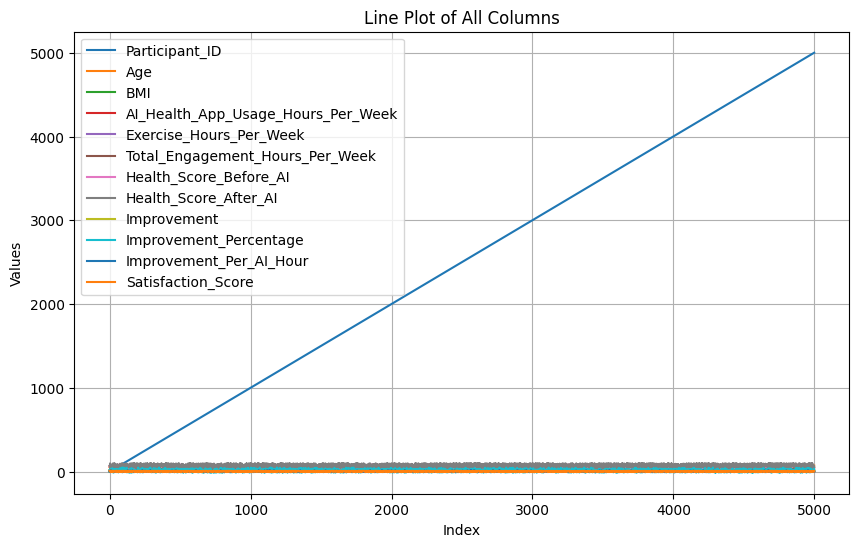

In [ ]:
import matplotlib.pyplot as plt

df.plot(kind='line', figsize=(10,6))

plt.title("Line Plot of All Columns")
plt.xlabel("Index")
plt.ylabel("Values")
plt.grid(True)
plt.show()

In [ ]:
# Label Enoding\
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [ ]:
# Exporting Label Encoder
import pickle
import pandas as pd # Ensure pandas is imported

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Label encode 'Gender' and assign to y
y = df['Gender']

# Create X by dropping 'Gender' and then one-hot encode remaining categorical columns
X_temp = df.drop(columns=['Gender']).copy()

# Identify categorical columns remaining in X_temp
categorical_cols_for_X = X_temp.select_dtypes(include='object').columns.tolist()

# One-hot encode these categorical columns
X = pd.get_dummies(X_temp, columns=categorical_cols_for_X, drop_first=True)

In [ ]:
#### Spliting into Training and Testing Dataset

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:

# Step 4: Initialize Decision Tree Classifier
# Re-training with the cleaned X_train_log and y_train_log
clf = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)

# Step 5: Train the model
clf.fit(X_train_log, y_train_log)

print("Decision Tree Classifier (clf) re-trained successfully with cleaned data.")


Decision Tree Classifier (clf) re-trained successfully with cleaned data.


In [ ]:
# Step 6: Make predictions with the re-trained clf model
y_pred = clf.predict(X_test_log)

# Step 7: Evaluate the re-trained clf model
accuracy_clf = accuracy_score(y_test_log, y_pred)
print("Accuracy (re-trained clf):", accuracy_clf)

# Also update y_pred_dt since the user typically used dt_model for the Decision Tree
y_pred_dt = y_pred


Accuracy (re-trained clf): 0.424


In [ ]:


le.classes_



array(['Female', 'Male', 'Other'], dtype=object)

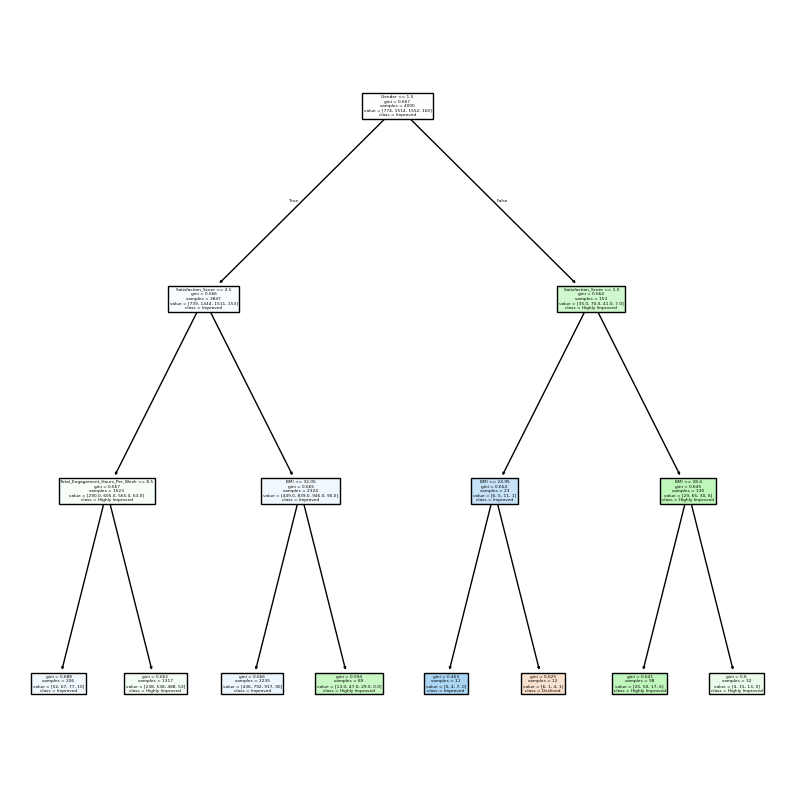

In [ ]:
import matplotlib.pyplot as plt
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(
    clf,
    feature_names=X_train_log.columns, # Use X_train_log.columns for correct feature names
    class_names=clf.classes_,
    filled=True
)
plt.show()


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Take Prediction on Single Data Point
# The model was trained on 31 features, so a single data point must also have 31 features.
# Instead of manually creating a 31-feature array, we can take an existing row from X_test_log for demonstration.
# Let's take the first row from X_test_log.

single_data_point = X_test_log.iloc[[0]]

# Make prediction
predicted_class_encoded = clf.predict(single_data_point)

# The original 'le' (LabelEncoder) was used for 'Gender', not for 'Improvement_Category'.
# To inverse transform 'Improvement_Category', we need a LabelEncoder fitted on 'y_logistic'.
# Let's create a new LabelEncoder for 'Improvement_Category' if 'le' is not suitable.

# Check if le is for 'Improvement_Category'
# Based on previous cells, `y_logistic` is the target for classification and `y_logistic` is `df['Improvement_Category']`
# The `clf.classes_` already holds the string labels. We can directly use these to interpret the prediction.

# The output of clf.predict for multiclass classification on string labels is already the string label.
# So, we can directly use the first element of the predicted array.
predicted_class_label = predicted_class_encoded[0]

print("Predicted class for a sample data point:", predicted_class_label)


Predicted class for a sample data point: Improved


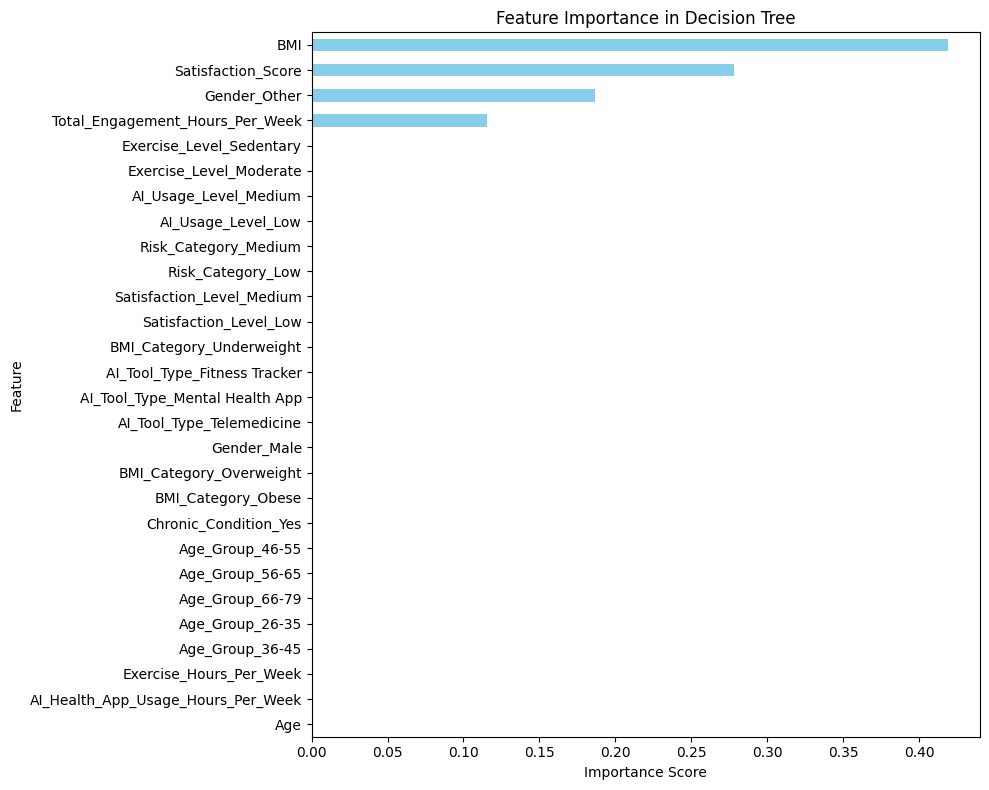

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance
# The model 'clf' was trained on X_train_log, so its feature importances correspond to X_train_log's columns.
feat_importance = pd.Series(clf.feature_importances_, index=X_train_log.columns)

# Plot
plt.figure(figsize=(10, 8))
feat_importance.sort_values().plot(kind='barh', color="skyblue")
plt.title("Feature Importance in Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


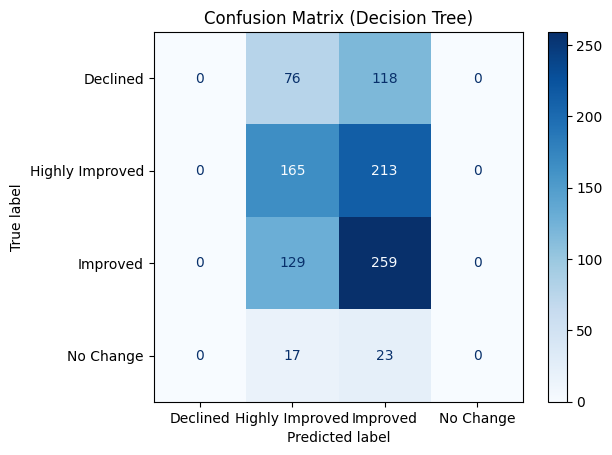

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion matrix for Decision Tree, using the correct test and predicted labels
# and the classifier's known class names.
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test_log,
    y_pred=y_pred_dt,
    display_labels=clf.classes_,
    cmap="Blues"
)
plt.title("Confusion Matrix (Decision Tree)")
plt.show()

In [ ]:
import pickle
# Exporting the trained model
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(clf, f)